In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [4]:
import wfdb
from scipy.signal import butter, filtfilt
import neurokit2 as nk
record = wfdb.rdrecord("100", pn_dir="mitdb")
signal = record.p_signal[:,0]
fs = record.fs
def bandpass(sig, fs, low=0.5, high=40):
    nyq = fs/2
    b,a = butter(4, [low/nyq, high/nyq], btype="band")
    return filtfilt(b,a,sig)

filtered = bandpass(signal, fs)

signals, info = nk.ecg_process(filtered, sampling_rate=fs)
rpeaks = info["ECG_R_Peaks"]

rr = np.diff(rpeaks)/fs
hr = 60/rr
t_hr = rpeaks[1:]/fs

hr_series = pd.Series(hr, index=pd.to_timedelta(t_hr, unit="s")) 

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\neurokit2\epochs\epochs_create.py:180: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  buffer.select_dtypes(exclude=["int", "int64"]).replace({0.0: np.nan}, inplace=True)
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\neurokit2\epochs\epoch

In [26]:
import pandas as pd

hr_series = pd.Series(
    hr,
    index=pd.to_timedelta(t_hr, unit="s")
)

# Sắp xếp thời gian
hr_series = hr_series.sort_index()

In [27]:
# Resample về 1 giây
hr_series = hr_series.resample("1s").mean()

# Nội suy (QUAN TRỌNG)
hr_series = hr_series.interpolate(limit_direction="both")

In [2]:
train_size = int(len(hr_series) * 0.7)

hr_train = hr_series.iloc[:train_size]
hr_test = hr_series.iloc[train_size:]

print("Total:", len(hr_series))
print("Train:", len(hr_train))
print("Test:", len(hr_test))

NameError: name 'hr_series' is not defined

In [29]:
from sklearn.metrics import mean_absolute_error

# giả sử bạn đã có pred
# pred = ...

if len(hr_test) == 0 or len(pred) == 0:
    print("❌ Dữ liệu rỗng → không tính được MAE")
else:
    mae = mean_absolute_error(hr_test, pred)
    print("MAE:", mae)

MAE: 5.044394444152639


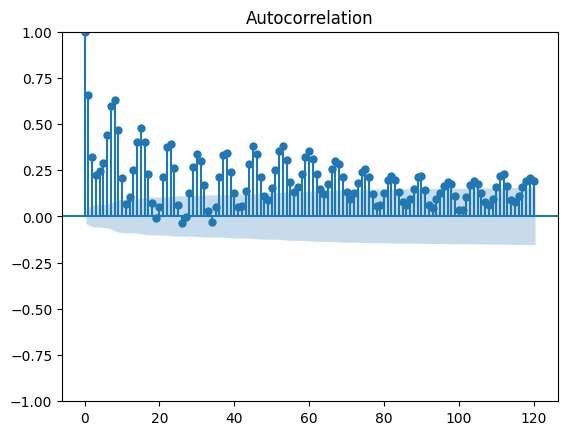

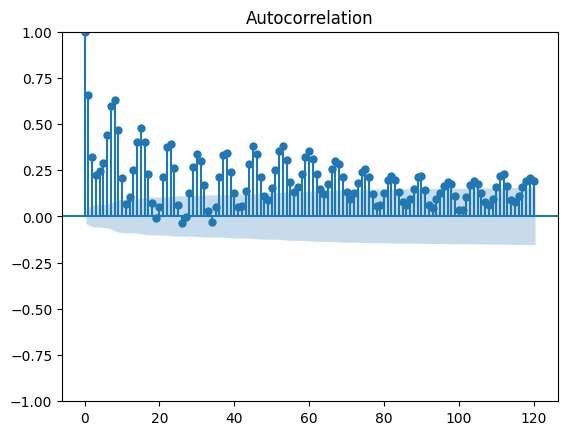

In [34]:
plot_acf(hr, lags=120)

In [32]:
model = SARIMAX(
    hr_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

result = model.fit(disp=False)

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [1]:
import pmdarima as pm

model = pm.auto_arima(
    hr_train,
    seasonal=False,   # rất quan trọng: dữ liệu của bạn gần như không có seasonality
    stepwise=True,
    trace=True
)

NameError: name 'hr_train' is not defined

In [37]:
pred = result.forecast(steps=len(hr_test))
pred.index = hr_test.index

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


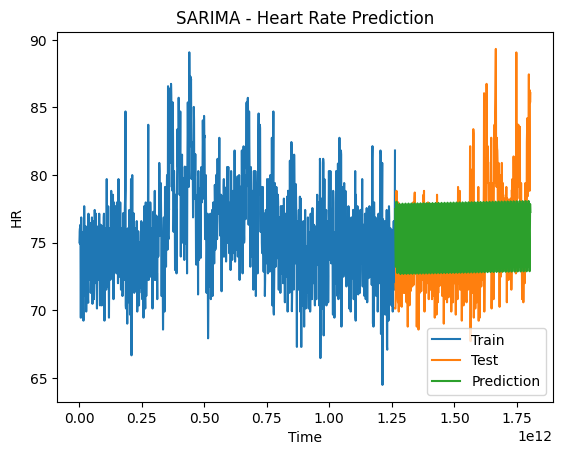

In [38]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(hr_train, label="Train")
plt.plot(hr_test, label="Test")
plt.plot(pred, label="Prediction")

plt.legend()
plt.title("SARIMA - Heart Rate Prediction")
plt.xlabel("Time")
plt.ylabel("HR")

plt.show()